In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ds_salaries.csv')
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/ds_salaries.csv'

In [2]:
import os
print(os.listdir('../data'))

[]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ds_salaries.csv')
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/ds_salaries.csv'

In [5]:
import os
print(os.getcwd())
print(os.listdir('../data'))

/Users/abdul/salary-predictor/notebooks
[]


In [6]:
import os
print(os.listdir('/Users/abdul/salary-predictor'))

['requirements.txt', 'ds_salaries.csv', 'README.md', 'app.py', 'venv', 'data', 'notebooks']


In [7]:
import shutil
shutil.move('/Users/abdul/salary-predictor/ds_salaries.csv', '/Users/abdul/salary-predictor/data/ds_salaries.csv')

'/Users/abdul/salary-predictor/data/ds_salaries.csv'

In [8]:
df = pd.read_csv('../data/ds_salaries.csv')
print(df.shape)
df.head()

(607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [9]:
# check column types and nulls
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

Missing values:
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


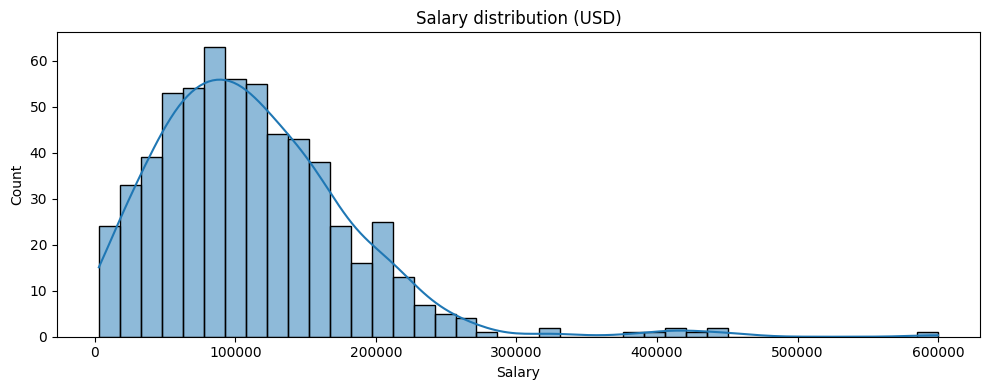

In [10]:
# see what the salary distribution looks like
plt.figure(figsize=(10, 4))
sns.histplot(df['salary_in_usd'], bins=40, kde=True)
plt.title('Salary distribution (USD)')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
# see unique values in key columns
print("Experience levels:", df['experience_level'].unique())
print("Employment types:", df['employment_type'].unique())
print("Company sizes:", df['company_size'].unique())
print("Remote ratio values:", df['remote_ratio'].unique())

Experience levels: ['MI' 'SE' 'EN' 'EX']
Employment types: ['FT' 'CT' 'PT' 'FL']
Company sizes: ['L' 'S' 'M']
Remote ratio values: [  0  50 100]


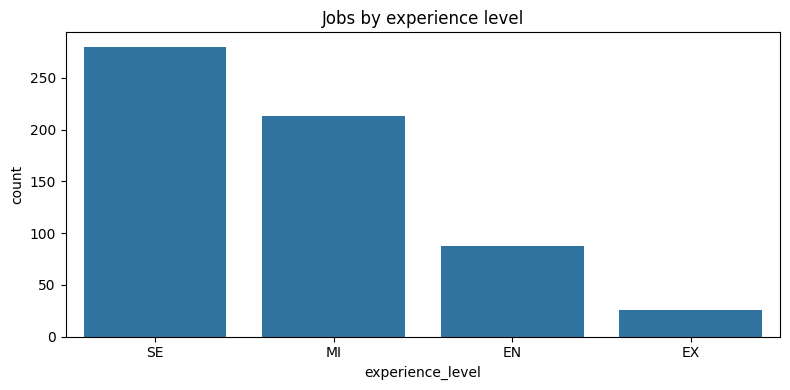

In [12]:
# see how many jobs per experience level
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='experience_level', order=df['experience_level'].value_counts().index)
plt.title('Jobs by experience level')
plt.tight_layout()
plt.show()

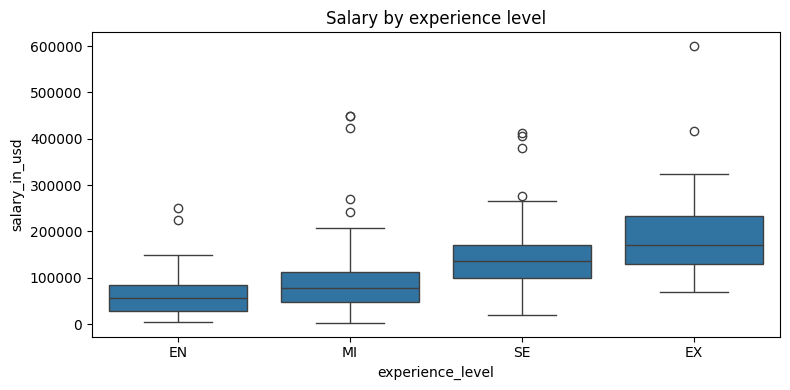

In [13]:
# average salary by experience level
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', 
            order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary by experience level')
plt.tight_layout()
plt.show()

In [14]:
# drop columns we don't need
df = df.drop(columns=['Unnamed: 0', 'salary', 'salary_currency'])

# encode categorical columns into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['experience_level', 'employment_type', 'job_title', 
            'employee_residence', 'company_location', 'company_size']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

   work_year  experience_level  employment_type  job_title  salary_in_usd  \
0       2020                 2                2         22          79833   
1       2020                 3                2         41         260000   
2       2020                 3                2          7         109024   
3       2020                 2                2         47          20000   
4       2020                 3                2         38         150000   

   employee_residence  remote_ratio  company_location  company_size  
0                  14             0                12             0  
1                  32             0                29             2  
2                  20            50                18             1  
3                  23             0                20             2  
4                  55            50                48             0  
work_year             int64
experience_level      int64
employment_type       int64
job_title             int64
salar

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# split into features and target
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print(f"R² score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")

R² score: 0.55
MAE: $27,713


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), 
                           param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Best params: {grid_search.best_params_}")
print(f"R² score: {r2_score(y_test, y_pred_best):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_best):,.0f}")

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
R² score: 0.56
MAE: $27,646


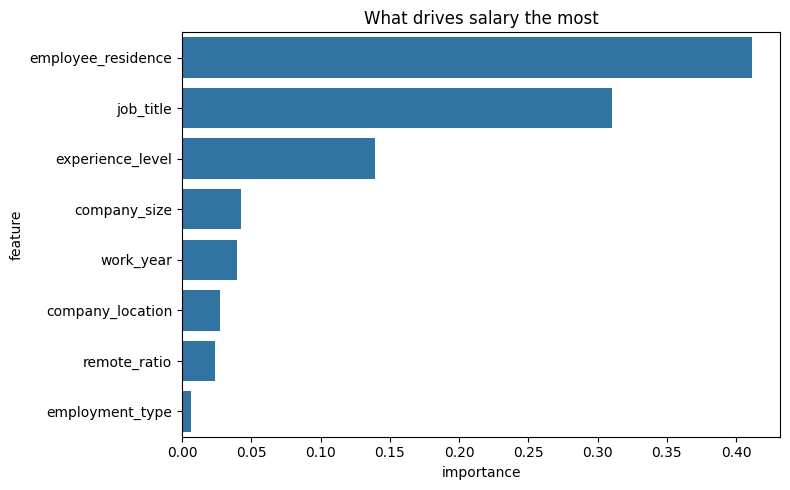

In [18]:
import pandas as pd

features = X.columns
importances = best_model.feature_importances_

feat_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='importance', y='feature')
plt.title('What drives salary the most')
plt.tight_layout()
plt.show()

In [19]:
import joblib
joblib.dump(best_model, '../model.pkl')
print("Model saved!")

Model saved!


In [20]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

model = joblib.load('model.pkl')

st.title('Data Science Salary Predictor')
st.write('Estimate your salary based on role, experience, and location.')

experience = st.selectbox('Experience level', ['EN', 'MI', 'SE', 'EX'])
employment = st.selectbox('Employment type', ['FT', 'PT', 'CT', 'FL'])
remote = st.selectbox('Remote ratio', [0, 50, 100])
company_size = st.selectbox('Company size', ['S', 'M', 'L'])
work_year = st.slider('Work year', 2020, 2023, 2023)

exp_map = {'EN': 0, 'MI': 2, 'SE': 3, 'EX': 1}
emp_map = {'CT': 0, 'FL': 1, 'FT': 2, 'PT': 3}
size_map = {'L': 0, 'M': 1, 'S': 2}

input_data = pd.DataFrame([{
    'work_year': work_year,
    'experience_level': exp_map[experience],
    'employment_type': emp_map[employment],
    'job_title': 22,
    'employee_residence': 55,
    'remote_ratio': remote,
    'company_location': 48,
    'company_size': size_map[company_size]
}])

if st.button('Predict salary'):
    prediction = model.predict(input_data)[0]
    st.metric('Estimated salary (USD)', f"${prediction:,.0f}")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

In [21]:
import joblib
joblib.dump(best_model, '../model.pkl')
print("Model saved!")

Model saved!


In [22]:
import json

# get original dataframe before encoding
df_original = pd.read_csv('../data/ds_salaries.csv')

# build mapping dicts
job_titles = sorted(df_original['job_title'].unique().tolist())
locations = sorted(df_original['employee_residence'].unique().tolist())
company_locations = sorted(df_original['company_location'].unique().tolist())

# get the encoded values
from sklearn.preprocessing import LabelEncoder

le_job = LabelEncoder()
le_res = LabelEncoder()
le_loc = LabelEncoder()

le_job.fit(df_original['job_title'])
le_res.fit(df_original['employee_residence'])
le_loc.fit(df_original['company_location'])

job_map = {title: int(le_job.transform([title])[0]) for title in job_titles}
res_map = {loc: int(le_res.transform([loc])[0]) for loc in locations}
loc_map = {loc: int(le_loc.transform([loc])[0]) for loc in company_locations}

# save to json files
with open('../job_map.json', 'w') as f:
    json.dump(job_map, f)
with open('../res_map.json', 'w') as f:
    json.dump(res_map, f)
with open('../loc_map.json', 'w') as f:
    json.dump(loc_map, f)

print(f"Jobs: {len(job_map)}, Locations: {len(res_map)}")

Jobs: 50, Locations: 57
